# Adversarial Attacks on Video Action Recognition

Every attack elsewhere in this repo perturbs a single static image. This notebook adds a **temporal** dimension: the target is now a whole video clip, classified by an action-recognition model rather than an object classifier.

**Model:** [MoViNet-A0](https://tfhub.dev/tensorflow/movinet/a0/base/kinetics-600/classification/3) (Kondratyuk et al., 2021), a compact, CPU-friendly video classifier from TensorFlow Hub, trained on **Kinetics-600** (600 human action classes). Unlike the streaming/recurrent variant used for real-time inference, we use the **base** variant, which consumes the entire clip in one forward pass, exactly what a gradient-based attack needs: one differentiable computation graph from the raw clip to the class logits.

**Attack:** the simplest and most direct generalization of the PGD attack already derived in `attacks/whitebox/02_PGD.ipynb`, applied to a clip instead of bounding a perturbation $\delta$ to a single `(H, W, 3)` image, we bound it to the whole `(T, H, W, 3)` clip and optimize all frames jointly:
$$x_{adv}^{t+1} = \Pi_{x+\mathcal{S}} \left( x_{adv}^t + \alpha \cdot sign(\nabla_x J(\theta, x_{adv}^t, y)) \right), \quad x \in \mathbb{R}^{T \times H \times W \times 3}$$
This is intentionally the naive baseline, not the state of the art: Wei et al. (2019, *"Sparse Adversarial Perturbations for Videos"*) and Li et al. (2019, *"Stealthy Adversarial Perturbations Against Real-Time Video Classification Systems"*) both show that perturbing only a handful of key frames, or exploiting temporal structure directly, fools video classifiers far more efficiently and imperceptibly than perturbing every frame equally. Whole-clip PGD is the right place to start, exactly like FGSM was the right place to start for images, before those sparser, more query-efficient techniques.


In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

C:\Users\frang\Desktop\adv_at\adversarial_attacks_vision\.venv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### Setup: Model, Demo Clip and Labels
The model, a short public domain "jumping jacks" GIF, and the Kinetics-600 label names are all pulled from TensorFlow's own MoViNet tutorial assets, the same clip used in the [official MoViNet documentation](https://www.tensorflow.org/hub/tutorials/movinet).

In [2]:
MOVINET_URL = 'https://tfhub.dev/tensorflow/movinet/a0/base/kinetics-600/classification/3'
VIDEO_URL = 'https://github.com/tensorflow/models/raw/f8af2291cced43fc9f1d9b41ddbf772ae7b0d7d2/official/projects/movinet/files/jumpingjack.gif'
LABELS_URL = 'https://raw.githubusercontent.com/tensorflow/models/f8af2291cced43fc9f1d9b41ddbf772ae7b0d7d2/official/projects/movinet/files/kinetics_600_labels.txt'

VIDEO_PATH = 'jumpingjack.gif'
LABELS_PATH = 'kinetics_600_labels.txt'

urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)
urllib.request.urlretrieve(LABELS_URL, LABELS_PATH)

with open(LABELS_PATH) as f:
    KINETICS_600_LABELS = [line.strip() for line in f.readlines()]
print(f"Loaded {len(KINETICS_600_LABELS)} Kinetics-600 class names")

print("Loading MoViNet-A0 (this downloads ~/.cache the first time it runs)...")
movinet = hub.load(MOVINET_URL)
movinet_signature = movinet.signatures['serving_default']

Loaded 600 Kinetics-600 class names
Loading MoViNet-A0 (this downloads ~/.cache the first time it runs)...



In [3]:
def load_video(path, target_size=(172, 172)):
    """Decodes a GIF into a (1, T, H, W, 3) float32 tensor in [0, 1], MoViNet's expected input format."""
    raw = tf.io.read_file(path)
    frames = tf.io.decode_gif(raw)  # (T, H, W, 3), uint8
    frames = tf.image.resize(tf.cast(frames, tf.float32), target_size) / 255.0
    return tf.expand_dims(frames, axis=0)

def predict_video(video):
    """Runs the base (non-streaming) MoViNet on a whole clip in one forward pass."""
    return movinet_signature(image=video)['classifier_head']

video = load_video(VIDEO_PATH)
print(f"Clip shape: {video.shape} (batch, frames, height, width, channels)")

clean_logits = predict_video(video)
true_idx = int(tf.argmax(clean_logits, axis=-1)[0])
print(f"Baseline prediction: '{KINETICS_600_LABELS[true_idx]}' (class {true_idx})")

Clip shape: (1, 13, 172, 172, 3) (batch, frames, height, width, channels)


Baseline prediction: 'jumping jacks' (class 242)


### Whole-Clip FGSM / PGD
Identical logic to `attacks/whitebox/01_FGSM.ipynb` and `attacks/whitebox/02_PGD.ipynb`; the only difference is that `img` is now 5-dimensional `(batch, frames, height, width, channels)` instead of 4-dimensional. Every TensorFlow op involved (`sign`, `clip_by_value`, `GradientTape`) is shape-agnostic, so the exact same code generalizes without modification: the attack does not need to know it is looking at a video instead of a single image.

In [4]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

def fgsm_attack_video(video, true_idx, epsilon):
    true_idx_tensor = tf.constant([true_idx])  # a bare Python list is treated as a nested
    # structure by Keras 3's tree utilities, not a 1-D array, so it must be a tensor already
    with tf.GradientTape() as tape:
        tape.watch(video)
        logits = predict_video(video)
        loss = loss_object(true_idx_tensor, logits)
    grad = tape.gradient(loss, video)
    return tf.clip_by_value(video + epsilon * tf.sign(grad), 0.0, 1.0)

def pgd_attack_video(video, true_idx, epsilon, iters=10):
    true_idx_tensor = tf.constant([true_idx])
    alpha = epsilon / (iters / 2.0)
    adv_video = tf.identity(video)
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv_video)
            logits = predict_video(adv_video)
            loss = loss_object(true_idx_tensor, logits)
        grad = tape.gradient(loss, adv_video)
        adv_video = adv_video + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(adv_video - video, -epsilon, epsilon)
        adv_video = tf.clip_by_value(video + perturbation, 0.0, 1.0)
    return adv_video

### Evaluation
We sweep $\varepsilon$ (in the same `[0, 1]`-normalized units MoViNet expects) and check, for both attacks, whether the predicted action changes, plus the $L_2$ distortion across the whole clip, for comparability with the per-image metric used everywhere else in the repo.

In [5]:
EPSILONS = [0.01, 0.03, 0.05, 0.1]

print(f"{'Epsilon':>8} | {'Attack':>6} | {'Predicted Class':<30} | {'Success':>7} | {'L2':>8}")
print('-' * 75)

for epsilon in EPSILONS:
    adv_fgsm = fgsm_attack_video(video, true_idx, epsilon)
    fgsm_idx = int(tf.argmax(predict_video(adv_fgsm), axis=-1)[0])
    fgsm_l2 = float(tf.norm(adv_fgsm - video))
    print(f"{epsilon:>8.2f} | {'FGSM':>6} | {KINETICS_600_LABELS[fgsm_idx]:<30} | {str(fgsm_idx != true_idx):>7} | {fgsm_l2:>8.2f}")

    adv_pgd = pgd_attack_video(video, true_idx, epsilon, iters=10)
    pgd_idx = int(tf.argmax(predict_video(adv_pgd), axis=-1)[0])
    pgd_l2 = float(tf.norm(adv_pgd - video))
    print(f"{epsilon:>8.2f} | {'PGD':>6} | {KINETICS_600_LABELS[pgd_idx]:<30} | {str(pgd_idx != true_idx):>7} | {pgd_l2:>8.2f}")

 Epsilon | Attack | Predicted Class                | Success |       L2
---------------------------------------------------------------------------


    0.01 |   FGSM | spinning poi                   |    True |    10.35


    0.01 |    PGD | spinning poi                   |    True |     6.82


    0.03 |   FGSM | spinning poi                   |    True |    31.04


    0.03 |    PGD | spinning poi                   |    True |    18.07


    0.05 |   FGSM | spinning poi                   |    True |    51.71


    0.05 |    PGD | spinning poi                   |    True |    29.65


    0.10 |   FGSM | spinning poi                   |    True |   103.34


    0.10 |    PGD | spinning poi                   |    True |    58.75


### Visualizing the Attack
A handful of frames from the original clip against the same frames from the strongest PGD adversarial clip, with the (unchanged) ground-truth action label on top and the model's prediction underneath each row.

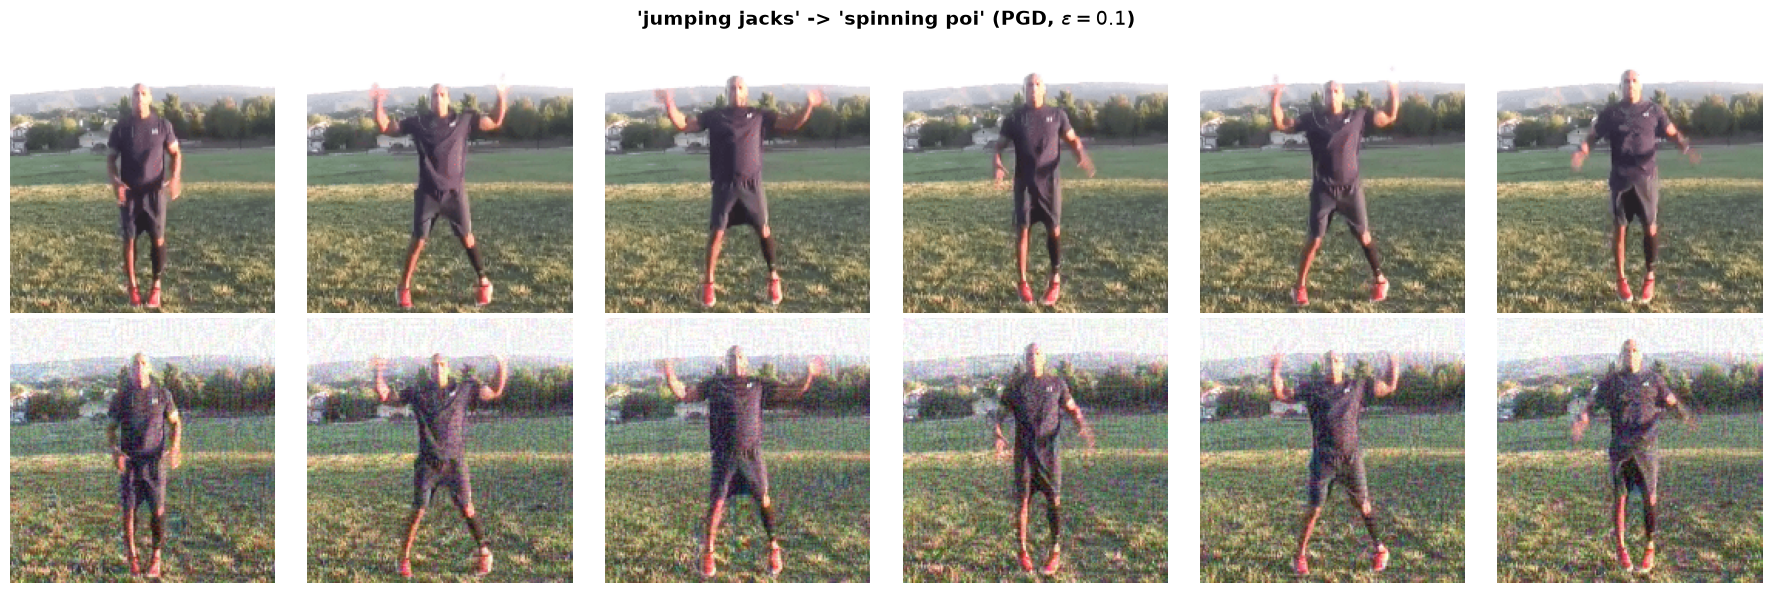

In [6]:
strongest_epsilon = EPSILONS[-1]
adv_video = pgd_attack_video(video, true_idx, strongest_epsilon, iters=10)
adv_idx = int(tf.argmax(predict_video(adv_video), axis=-1)[0])

num_frames_to_show = 6
frame_indices = np.linspace(0, video.shape[1] - 1, num_frames_to_show).astype(int)

fig, axes = plt.subplots(2, num_frames_to_show, figsize=(3 * num_frames_to_show, 6))

for col, frame_idx in enumerate(frame_indices):
    axes[0, col].imshow(video[0, frame_idx].numpy())
    axes[0, col].axis('off')
    axes[1, col].imshow(adv_video[0, frame_idx].numpy())
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Adversarial', fontsize=12, fontweight='bold')
fig.suptitle(
    f"'{KINETICS_600_LABELS[true_idx]}' -> '{KINETICS_600_LABELS[adv_idx]}' "
    f"(PGD, $\\varepsilon={strongest_epsilon}$)",
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()